# DSC 291 HW4 — Part B: Classification from Pivoted Tables

Classify taxi type (yellow vs green) using XGBoost on PCA-reduced hourly profiles from pivoted (date × taxi_type × pickup_location × hour) tables.

## 1. Config

In [28]:
# Path to pivoted parquet (configurable)
PIVOT_PARQUET_PATH = "s3://291-s3-bucket/wide.parquet"
RANDOM_SEED = 42
TRAIN_FRAC = 0.80
N_PCA_COMPONENTS = 5

print("PIVOT_PARQUET_PATH", PIVOT_PARQUET_PATH)
print("RANDOM_SEED", RANDOM_SEED)
print("TRAIN_FRAC", TRAIN_FRAC)
print("N_PCA_COMPONENTS", N_PCA_COMPONENTS)
print('done')

PIVOT_PARQUET_PATH s3://291-s3-bucket/wide.parquet
RANDOM_SEED 42
TRAIN_FRAC 0.8
N_PCA_COMPONENTS 5
done


In [ ]:
import os
import re
import dask.dataframe as dd
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score


os.environ["AWS_ACCESS_KEY_ID"] = "..."
os.environ["AWS_SECRET_ACCESS_KEY"] = "..."
os.environ["AWS_SESSION_TOKEN"] = "..."



## 2. Load

Read pivoted parquet with Dask; keep rows with valid `taxi_type` and `hour_0`…`hour_23`; restrict to yellow and green.

In [30]:
# !pip install dask -q
# !pip install pyarrow - q
#!pip install s3fs -q
#!pip install xgboost -q

In [31]:
def _normalize_pivot_schema(ddf):
    """Normalize pivoted wide table columns."""
    cols = list(ddf.columns)
    index_level_cols = [c for c in cols if re.fullmatch(r"__index_level_\d+__", str(c))]
    if "taxi_type" not in cols and len(index_level_cols) >= 3:
        def _level_num(name):
            return int(re.findall(r"\d+", name)[0])
        il = sorted((str(c) for c in index_level_cols), key=_level_num)
        ddf = ddf.rename(columns={il[0]: "taxi_type", il[1]: "date", il[2]: "pickup_place"})
        cols = list(ddf.columns)
    if "taxi_type" not in cols:
        for c in ("taxi", "cab_type", "service_type", "taxitype"):
            if c in cols:
                ddf = ddf.rename(columns={c: "taxi_type"})
                break
    hour_cols = [c for c in ddf.columns if str(c).startswith("hour_")]
    if "taxi_type" not in ddf.columns or not hour_cols:
        raise KeyError(f"Missing taxi_type or hour_* columns. Got: {list(ddf.columns)[:20]}")
    return ddf


def load_pivot_for_partb(path=None):
    if path is None:
        path = PIVOT_PARQUET_PATH
    print(f"[Part B] Reading: {path}")
    try:
        ddf = dd.read_parquet(path, engine="pyarrow", index=False)
        ddf = _normalize_pivot_schema(ddf)
    except KeyError as e:
        print(f"[Part B] Dask schema failed ({e}). Falling back to pandas...")
        pdf = pd.read_parquet(path, engine="pyarrow")
        if isinstance(pdf.index, pd.MultiIndex) or pdf.index.name is not None:
            pdf = pdf.reset_index()
        ddf = dd.from_pandas(pdf, npartitions=1)
        ddf = _normalize_pivot_schema(ddf)
    ddf = ddf[ddf["taxi_type"].isin(["yellow", "green"])]
    df = ddf.compute()
    print(f"[Part B] Rows (yellow+green): {len(df):,}")
    return df


pivot_df = load_pivot_for_partb()
pivot_df.head()

[Part B] Reading: s3://291-s3-bucket/wide.parquet
[Part B] Rows (yellow+green): 2,053,698


,taxi_type,date,pickup_place,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,yellow,2009-01-01,-73.137_41.366,60,67,57,44,25,20,6,...,46,41,53,55,43,36,41,43,41,18
1,yellow,2009-01-01,-73.777_40.645,4,2,1,0,0,10,12,...,56,26,56,45,38,72,46,46,60,28
2,yellow,2009-01-01,-73.777_40.646,3,1,0,0,0,1,2,...,9,10,5,4,2,2,9,7,4,5
3,yellow,2009-01-01,-73.781_40.645,3,0,0,0,0,0,0,...,3,1,6,4,3,1,7,4,4,10
4,yellow,2009-01-01,-73.782_40.645,22,20,9,6,0,5,15,...,39,46,67,53,47,35,33,18,40,54


## 3. Features

Convert hourly counts to row proportions; fit PCA on the 24-dimensional profile; use PC1–PC5 as features.

In [32]:
HOUR_COLS = [f"hour_{i}" for i in range(24)]
profile = pivot_df[HOUR_COLS].values.astype(float)

# Row proportions (avoid division by zero)
row_sums = profile.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid 0/0
proportions = profile / row_sums

# Drop rows with all zeros (invalid profile)
valid = (profile.sum(axis=1) > 0)
proportions_valid = proportions[valid]
taxi_labels = pivot_df.loc[valid, "taxi_type"].values

print(f"Valid rows: {proportions_valid.shape[0]:,}")
print(f"Profile shape: {proportions_valid.shape}")

Valid rows: 2,053,698
Profile shape: (2053698, 24)


In [33]:
# Fit PCA and transform
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(proportions_valid)

print("Variance explained by component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f}")

X = X_pca
y_raw = taxi_labels

Variance explained by component:
  PC1: 0.2821
  PC2: 0.1336
  PC3: 0.1225
  PC4: 0.0521
  PC5: 0.0412
  Total: 0.6315


## 4. Train and Evaluate

In [34]:
# Encode taxi_type
le = LabelEncoder()
y = le.fit_transform(y_raw)
classes = le.classes_
n_class = len(classes)
print(f"Classes: {classes} -> 0..{n_class-1}")

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=TRAIN_FRAC, stratify=y, random_state=RANDOM_SEED
)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

Classes: ['green' 'yellow'] -> 0..1
Train: 1,642,958, Test: 410,740


In [35]:
# Fit XGBClassifier
clf = XGBClassifier(
    objective="multi:softmax",
    num_class=n_class,
    random_state=RANDOM_SEED,
    use_label_encoder=False,
    eval_metric="mlogloss",
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

/Users/nannu/anaconda3/envs/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:21:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9112

Classification Report:
              precision    recall  f1-score   support

       green       0.59      0.05      0.10     37093
      yellow       0.91      1.00      0.95    373647

    accuracy                           0.91    410740
   macro avg       0.75      0.52      0.52    410740
weighted avg       0.88      0.91      0.88    410740



## 5. Interpret

Plot confusion matrix and feature importance (which PCs matter most).

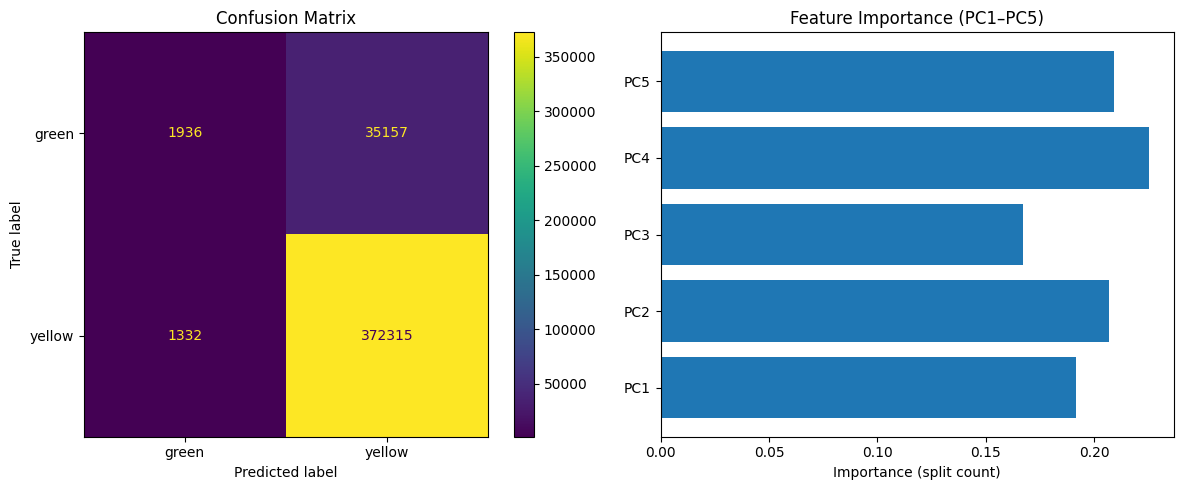

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=classes, ax=axes[0], colorbar=True
)
axes[0].set_title("Confusion Matrix")

# Feature importance (PCs)
importance = clf.feature_importances_
pc_names = [f"PC{i+1}" for i in range(N_PCA_COMPONENTS)]
axes[1].barh(pc_names, importance)
axes[1].set_xlabel("Importance (split count)")
axes[1].set_title("Feature Importance (PC1–PC5)")

plt.tight_layout()
plt.show()

## 6. Extra Credit: Bootstrap Stability + Prediction Confidence

Use bootstrap to evaluate stability of metrics and prediction confidence.

In [37]:
N_BOOTSTRAP = 200  # number of bootstrap iterations
np.random.seed(RANDOM_SEED)

In [38]:
# Bootstrap stability: resample test set B times, compute accuracy & F1
n_test = len(y_test)
acc_boot = []
f1_boot = []
for _ in range(N_BOOTSTRAP):
    idx = np.random.choice(n_test, size=n_test, replace=True)
    acc_boot.append(accuracy_score(y_test[idx], y_pred[idx]))
    f1_boot.append(f1_score(y_test[idx], y_pred[idx], average="weighted", zero_division=0))

acc_boot = np.array(acc_boot)
f1_boot = np.array(f1_boot)
acc_ci = np.percentile(acc_boot, [2.5, 97.5])
f1_ci = np.percentile(f1_boot, [2.5, 97.5])

print("Bootstrap stability (test set resampling):")
print(f"  Accuracy: {acc_boot.mean():.4f} ± {acc_boot.std():.4f}  95% CI: [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]")
print(f"  F1 (weighted): {f1_boot.mean():.4f} ± {f1_boot.std():.4f}  95% CI: [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")

Bootstrap stability (test set resampling):
  Accuracy: 0.9112 ± 0.0004  95% CI: [0.9104, 0.9119]
  F1 (weighted): 0.8759 ± 0.0006  95% CI: [0.8748, 0.8769]


In [39]:
# Prediction confidence: max predicted probability per sample
y_proba = clf.predict_proba(X_test)
confidences = np.max(y_proba, axis=1)
correct = (y_pred == y_test)
conf_correct = confidences[correct]
conf_incorrect = confidences[~correct]

print("Prediction confidence:")
print(f"  Mean confidence (correct):   {conf_correct.mean():.4f} ± {conf_correct.std():.4f}")
print(f"  Mean confidence (incorrect): {conf_incorrect.mean():.4f} ± {conf_incorrect.std():.4f}")

Prediction confidence:
  Mean confidence (correct):   0.9206 ± 0.0820
  Mean confidence (incorrect): 0.8159 ± 0.1264


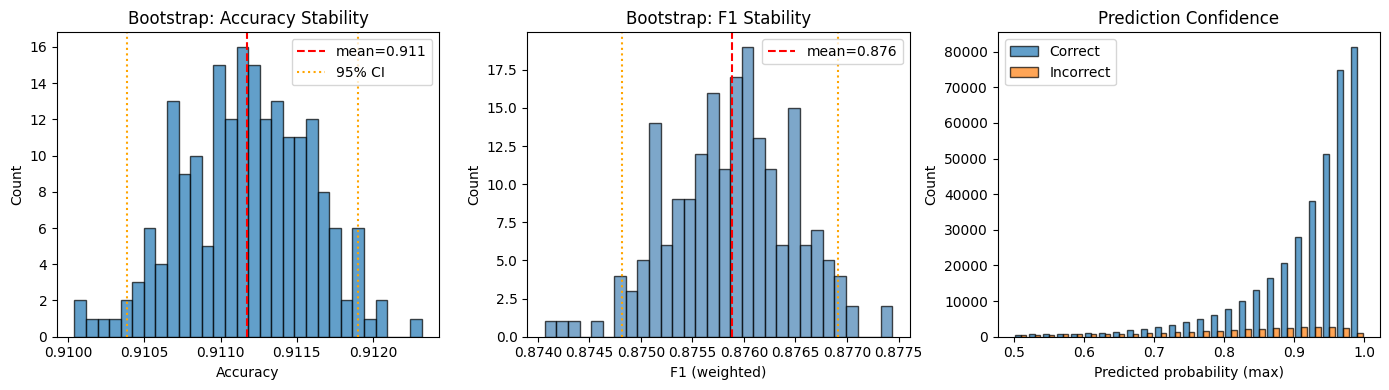

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Bootstrap distribution of accuracy
axes[0].hist(acc_boot, bins=30, edgecolor="black", alpha=0.7)
axes[0].axvline(acc_boot.mean(), color="red", ls="--", label=f"mean={acc_boot.mean():.3f}")
axes[0].axvline(acc_ci[0], color="orange", ls=":", label="95% CI")
axes[0].axvline(acc_ci[1], color="orange", ls=":")
axes[0].set_xlabel("Accuracy")
axes[0].set_ylabel("Count")
axes[0].set_title("Bootstrap: Accuracy Stability")
axes[0].legend()

# Bootstrap distribution of F1
axes[1].hist(f1_boot, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(f1_boot.mean(), color="red", ls="--", label=f"mean={f1_boot.mean():.3f}")
axes[1].axvline(f1_ci[0], color="orange", ls=":")
axes[1].axvline(f1_ci[1], color="orange", ls=":")
axes[1].set_xlabel("F1 (weighted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Bootstrap: F1 Stability")
axes[1].legend()

# Prediction confidence: correct vs incorrect
axes[2].hist([conf_correct, conf_incorrect], bins=25, label=["Correct", "Incorrect"], alpha=0.7, edgecolor="black")
axes[2].set_xlabel("Predicted probability (max)")
axes[2].set_ylabel("Count")
axes[2].set_title("Prediction Confidence")
axes[2].legend()

plt.tight_layout()
plt.show()